In [ ]:
# ==========================================
# DECISION TREE & RANDOM FOREST (TỰ XÂY THƯ VIỆN)
# ==========================================

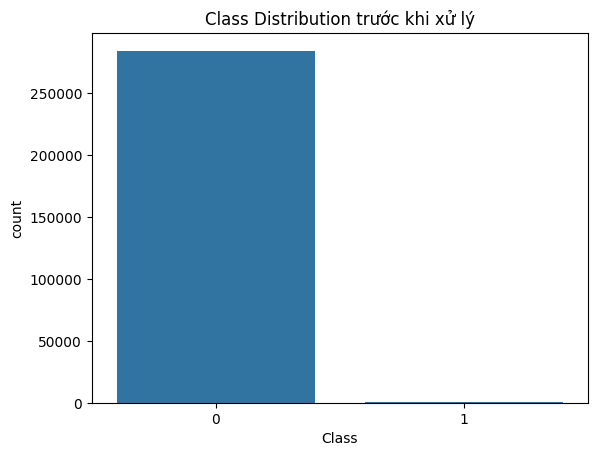

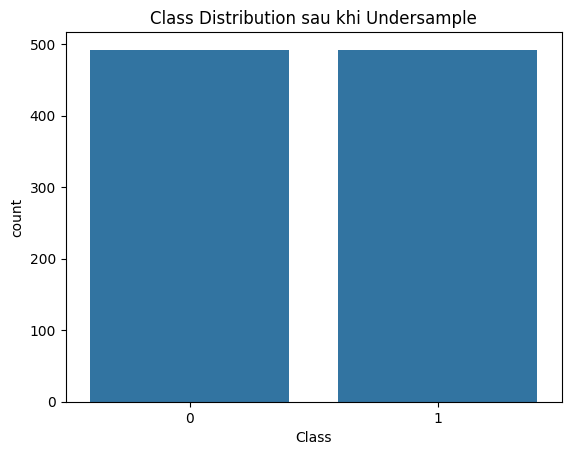

Tree 1/10 done
Tree 2/10 done
Tree 3/10 done
Tree 4/10 done
Tree 5/10 done
Tree 6/10 done
Tree 7/10 done
Tree 8/10 done
Tree 9/10 done
Tree 10/10 done
=== TRAIN ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       394
           1       0.99      0.98      0.99       393

    accuracy                           0.99       787
   macro avg       0.99      0.99      0.99       787
weighted avg       0.99      0.99      0.99       787

ROC AUC Score:  0.9898283411477505
=== TEST ===
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        98
           1       0.96      0.89      0.92        99

    accuracy                           0.92       197
   macro avg       0.93      0.92      0.92       197
weighted avg       0.93      0.92      0.92       197

ROC AUC Score:  0.9240362811791383


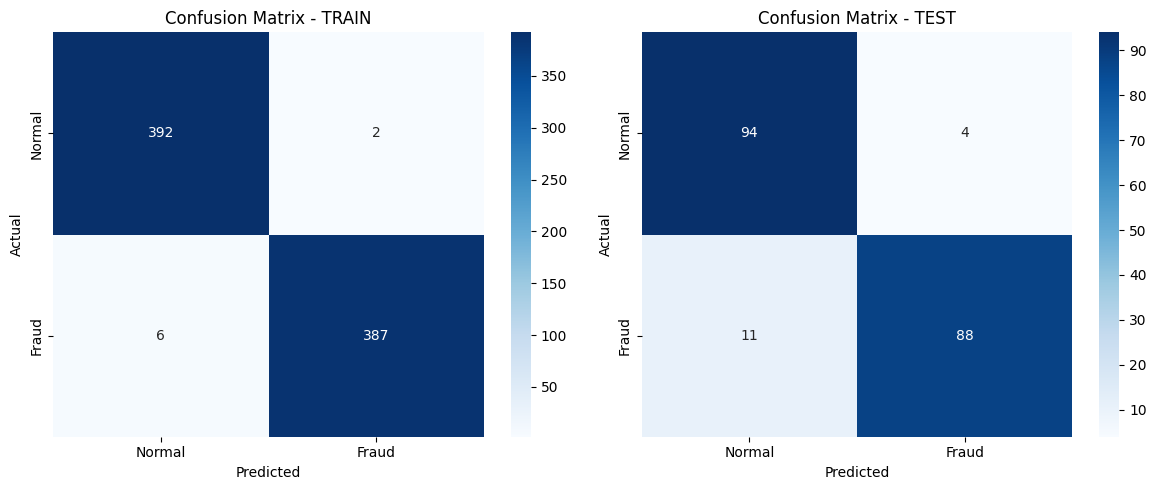

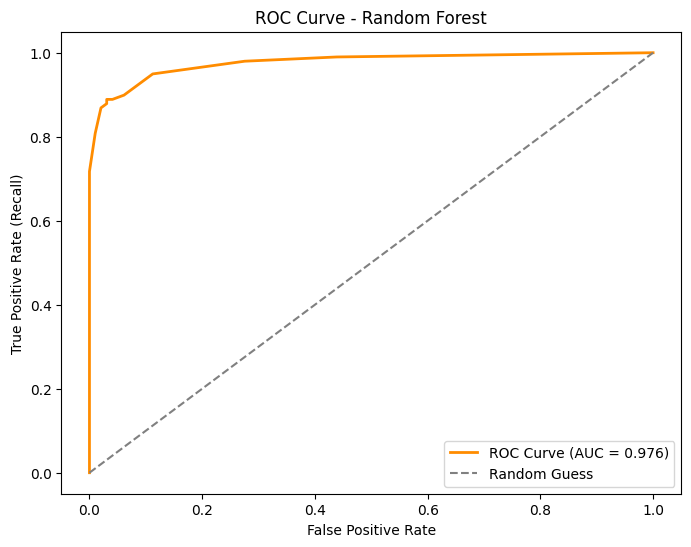

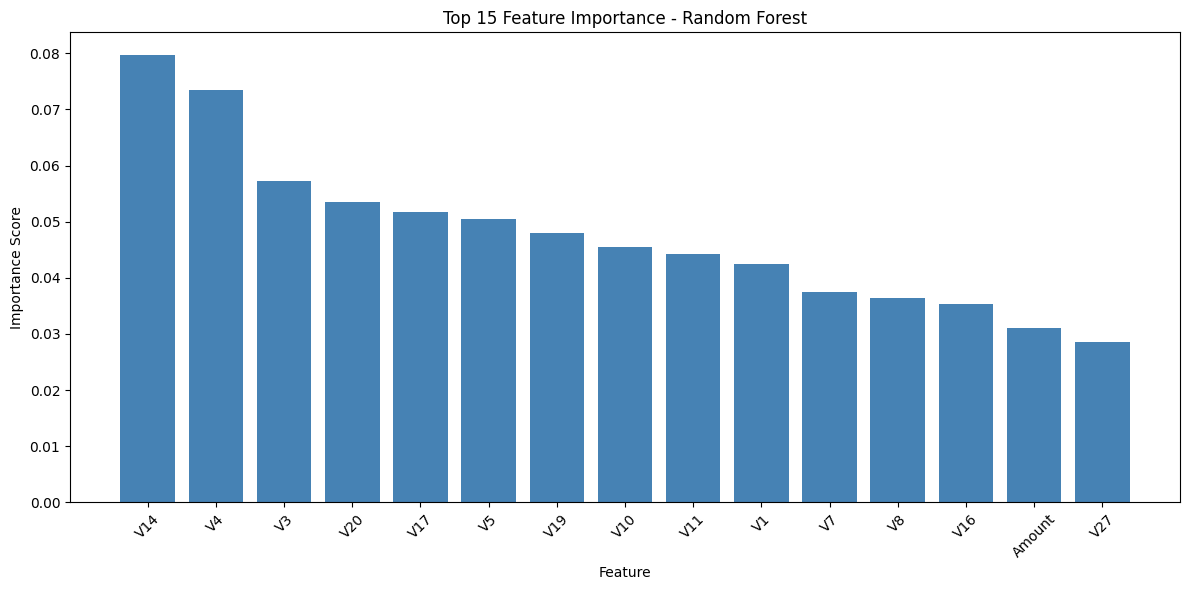


Top 5 features quan trọng nhất:
1. V14: 0.0798
2. V4: 0.0735
3. V3: 0.0572
4. V20: 0.0535
5. V17: 0.0517


In [14]:
# ==========================================
# BƯỚC 1 — Import
# ==========================================
import pandas as pd
import numpy as np
import seaborn as sns
import sqlite3
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score as roc
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# ==========================================
# BƯỚC 2 — Tự build Decision Tree + Random Forest
# ==========================================

class Node:
    def __init__(self):
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None
        self.value = None


class DecisionTree:
    def __init__(self, max_depth=None, max_features=None):
        self.max_depth = max_depth
        self.max_features = max_features
        self.root = None
        self.feature_importances_ = None

    def _gini(self, y):
        counts = Counter(y)
        n = len(y)
        impurity = 1.0
        for count in counts.values():
            impurity -= (count / n) ** 2
        return impurity

    def _best_split(self, X, y):
        best_gini = float('inf')
        best_feature = None
        best_threshold = None
        n_features = X.shape[1]

        if self.max_features:
            feature_indices = np.random.choice(n_features, self.max_features, replace=False)
        else:
            feature_indices = range(n_features)

        for feature in feature_indices:
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                n = len(y)
                gini = (len(y_left) / n) * self._gini(y_left) + \
                       (len(y_right) / n) * self._gini(y_right)

                if gini < best_gini:
                    best_gini = gini
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth=0):
        node = Node()

        if len(set(y)) == 1:
            node.value = y[0]
            return node

        if self.max_depth and depth >= self.max_depth:
            node.value = Counter(y).most_common(1)[0][0]
            return node

        if len(y) < 2:
            node.value = y[0]
            return node

        feature, threshold = self._best_split(X, y)

        if feature is None:
            node.value = Counter(y).most_common(1)[0][0]
            return node

        # Ghi lại feature nào được dùng để split
        self.feature_importances_[feature] += 1

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        node.feature = feature
        node.threshold = threshold
        node.left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        node.right = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return node

    def fit(self, X, y):
        X = np.array(X)
        self.feature_importances_ = np.zeros(X.shape[1])
        self.root = self._build_tree(X, np.array(y))
        # Normalize
        total = self.feature_importances_.sum()
        if total > 0:
            self.feature_importances_ /= total

    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in np.array(X)])


class RandomForest:
    def __init__(self, n_estimators=100, max_depth=None, max_features='sqrt', random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []
        self.feature_importances_ = None

    def fit(self, X, y):
        if self.random_state:
            np.random.seed(self.random_state)

        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape

        if self.max_features == 'sqrt':
            max_feat = int(np.sqrt(n_features))
        else:
            max_feat = n_features

        self.feature_importances_ = np.zeros(n_features)
        self.trees = []

        for i in range(self.n_estimators):
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_boot = X[indices]
            y_boot = y[indices]

            tree = DecisionTree(max_depth=self.max_depth, max_features=max_feat)
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)

            # Cộng dồn feature importance từ mỗi cây
            self.feature_importances_ += tree.feature_importances_
            print(f"Tree {i+1}/{self.n_estimators} done")

        # Trung bình feature importance qua tất cả cây
        self.feature_importances_ /= self.n_estimators

    def predict(self, X):
        X = np.array(X)
        all_preds = np.array([tree.predict(X) for tree in self.trees])
        result = []
        for i in range(X.shape[0]):
            votes = all_preds[:, i]
            result.append(Counter(votes).most_common(1)[0][0])
        return np.array(result)

    def predict_proba(self, X):
        # Trả về xác suất fraud để vẽ ROC curve
        X = np.array(X)
        all_preds = np.array([tree.predict(X) for tree in self.trees])
        # Tỷ lệ cây vote là fraud (class 1)
        proba = all_preds.mean(axis=0)
        return proba


# ==========================================
# BƯỚC 3 — Load data qua SQLite
# ==========================================
df_raw = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')
conn = sqlite3.connect('credit_card.db')
df_raw.to_sql('transactions', conn, if_exists='replace', index=False)
dataset = pd.read_sql_query("SELECT * FROM transactions LIMIT 5", conn)
dataset.head()

# ==========================================
# BƯỚC 4 — Visualize imbalance
# ==========================================
all_data = pd.read_sql_query("SELECT Class FROM transactions", conn)
sns.countplot(x='Class', data=all_data)
plt.title('Class Distribution trước khi xử lý')
plt.show()

# ==========================================
# BƯỚC 5 — Tách fraud/normal qua SQL
# ==========================================
positiveDataset = pd.read_sql_query("SELECT * FROM transactions WHERE Class = 1", conn)
negativeDataset = pd.read_sql_query("SELECT * FROM transactions WHERE Class = 0", conn)
conn.close()

# ==========================================
# BƯỚC 6 — Undersampling
# ==========================================
negativeDataset_down = resample(
    negativeDataset,
    n_samples=len(positiveDataset),
    random_state=21
)
balancedDataset = pd.concat([positiveDataset, negativeDataset_down])

sns.countplot(x='Class', data=balancedDataset)
plt.title('Class Distribution sau khi Undersample')
plt.show()

# ==========================================
# BƯỚC 7 — Split train/test
# ==========================================
X = balancedDataset.drop(columns=['Class'])
y = balancedDataset['Class']

xTrain, xTest, yTrain, yTest = tts(
    X, y,
    test_size=0.2,
    random_state=21,
    stratify=y
)

# ==========================================
# BƯỚC 8 — Scale
# ==========================================
scaler = StandardScaler()
xTrain = scaler.fit_transform(xTrain)
xTest = scaler.transform(xTest)

# ==========================================
# BƯỚC 9 — Train
# ==========================================
classifier = RandomForest(n_estimators=10, max_depth=10, random_state=21)
classifier.fit(xTrain, yTrain)

# ==========================================
# BƯỚC 10 — Evaluate
# ==========================================
predTrain = classifier.predict(xTrain)
print("=== TRAIN ===")
print(classification_report(yTrain, predTrain))
print('ROC AUC Score: ', roc(yTrain, predTrain))

predTest = classifier.predict(xTest)
print("=== TEST ===")
print(classification_report(yTest, predTest))
print('ROC AUC Score: ', roc(yTest, predTest))

# ==========================================
# BƯỚC 11 — Confusion Matrix
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train
cm_train = confusion_matrix(yTrain, predTrain)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
axes[0].set_title('Confusion Matrix - TRAIN')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Test
cm_test = confusion_matrix(yTest, predTest)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
axes[1].set_title('Confusion Matrix - TEST')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ==========================================
# BƯỚC 12 — ROC Curve
# ==========================================
proba_test = classifier.predict_proba(xTest)
fpr, tpr, _ = roc_curve(yTest, proba_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

# ==========================================
# BƯỚC 13 — Feature Importance
# ==========================================
feature_names = balancedDataset.drop(columns=['Class']).columns
importances = classifier.feature_importances_

# Sort theo importance
indices = np.argsort(importances)[::-1]
top_n = 15  # lấy top 15 features quan trọng nhất

plt.figure(figsize=(12, 6))
plt.bar(range(top_n),
        importances[indices[:top_n]],
        color='steelblue')
plt.xticks(range(top_n),
           [feature_names[i] for i in indices[:top_n]],
           rotation=45)
plt.title('Top 15 Feature Importance - Random Forest')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

# In ra top 5
print("\nTop 5 features quan trọng nhất:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")